PyTorch implementation of the **All Convolutional Net** discussed in _'Striving for Simplicity: The All Convolutional Net'_ (Springenberg et al., 2014)

In [1]:
import os
import time     # for recording training duration
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl

First, we implement a standard CNN with max-pooling layers to compare with its AllConv counterpart containing only convolutional layers. To understand the impact of data augmentation and batch normalisation on the results, we will create models with/without them for both cases.

We will evaluate the accuracy of these models on the CIFAR-10 dataset.

For reproducibility of results, we'll use a specific random seed, and also force determinism in cuDNN.

In [4]:
seed = 26

os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # forces cuDNN to use deterministic algorithms only
    torch.backends.cudnn.deterministic = True
    # disables cuDNN autotuner that selects optimal algorithm based on hardware
    torch.backends.cudnn.benchmark = False

# force shuffling of samples in dataloader to be deterministic
generator = torch.Generator().manual_seed(seed)

In [5]:
# hyperparameters
learningrate = 0.01
batchsize = 128
epochs = 100

momentum = 0.9

In [6]:
datapath = '../data'

# loading CIFAR-10 dataset
train_cifar10 = datasets.CIFAR10(
    root=datapath,
    train=True,
    download=True,
    transform=transforms.ToTensor()     # here, transforms.toTensor() also normalises pixel values to [0, 1]
)
test_cifar10 = datasets.CIFAR10(
    root=datapath,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

# setting up dataloaders
trainloader_cifar10 = DataLoader(
    train_cifar10, 
    batch_size=batchsize,
    generator=generator,
    shuffle=True                        # allows samples to be distributed among classes to reduce bias
)
testloader_cifar10 = DataLoader(
    test_cifar10, 
    batch_size=batchsize,
    shuffle=False
)

In [7]:
# retrieving class names
with open(datapath + "/cifar-10-batches-py/batches.meta", "rb") as f:
    metadata = pkl.load(f, encoding="ASCII")
    classes = metadata["label_names"]

print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


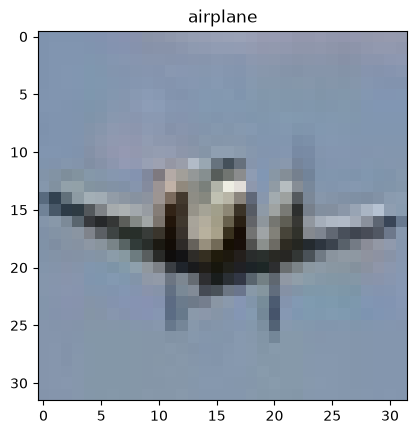

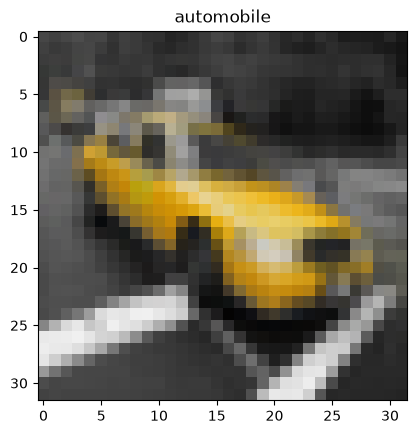

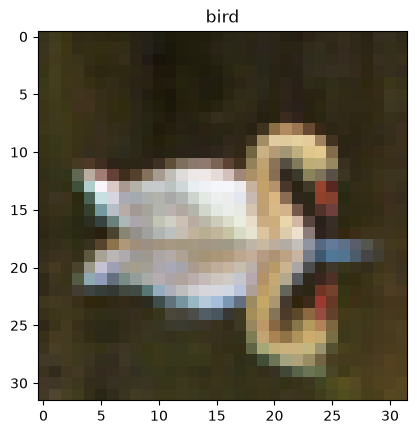

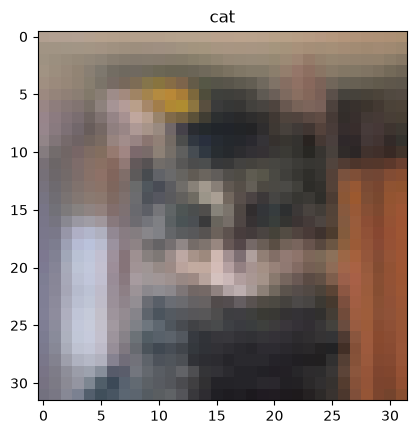

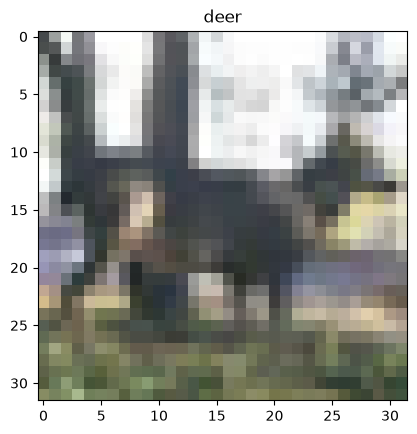

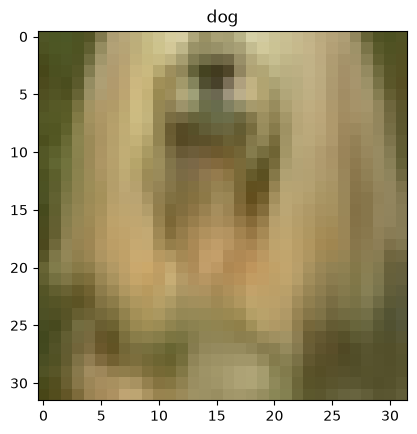

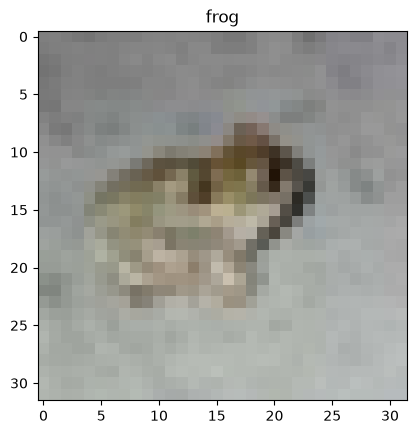

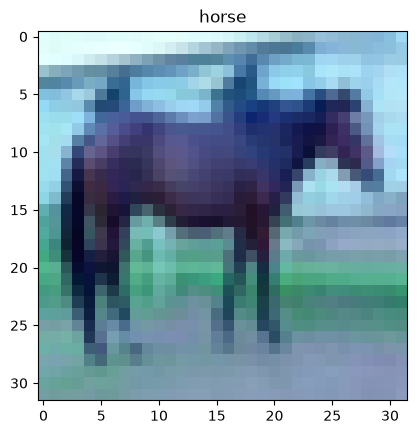

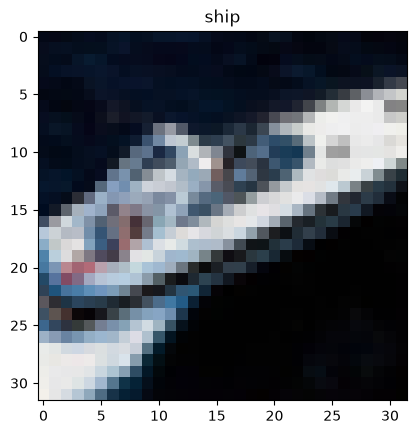

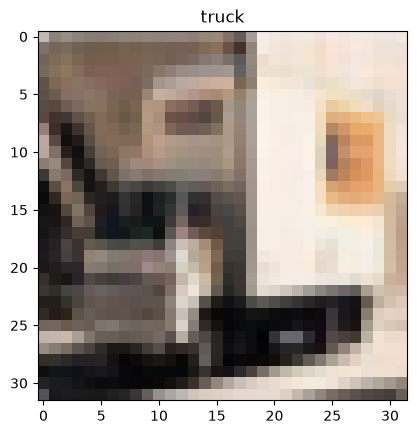

In [8]:
# retrieve a batch from training data (cifar10 is divided into five batches of 10k)
images, labels = next(iter(trainloader_cifar10))
# display an example image from each class
for i in range(10):
    index = np.argmax(labels.numpy() == i)
    plt.imshow(images[index].permute(1, 2, 0))     # permute to (H, W, C) for plotting
    plt.title(classes[labels[index]])
    plt.show()


We now implement the AllConv class, along with a BaseCNN class for comparison, referring to the architectures described in the allconv paper. We will initially evaluate accuracy without applying regularisation methods such as dropout and batch normalisation.

In [ ]:
class AllConv(nn.Module):
    def __init__(self, inputsize, classcount, flag_dropout=True, flag_batchnorm=False):
        super().__init__()                          # AllConv class inherits from nn.Module, so this initialises an instance of parent class

        # the paper applies dropout of 0.2 to inputs and 0.5 after each pooling layer
        # uses a flag to test how using dropout affects accuracy
        self.dropout = flag_dropout
        self.batchnorm = flag_batchnorm

        # these are PyTorch classes in the nn module, so create an instance before calling
        self.conv1 = nn.Conv2d(in_channels = inputsize, out_channels = 96, kernel_size = 3, padding = 1)
        self.bn1 = nn.BatchNorm2d(num_features = 96) if flag_batchnorm else nn.Identity()
        self.conv2 = nn.Conv2d(in_channels = 96, out_channels = 96, kernel_size = 3, padding = 1)
        self.bn2 = nn.BatchNorm2d(num_features = 96) if flag_batchnorm else nn.Identity()
        # now, replace first maxpool with strided conv
        self.conv3 = nn.Conv2d(in_channels = 96, out_channels = 96, kernel_size = 3, padding = 1, stride = 2)
        self.bn3 = nn.BatchNorm2d(num_features = 96) if flag_batchnorm else nn.Identity()

        self.conv4 = nn.Conv2d(in_channels = 96, out_channels = 192, kernel_size = 3, padding = 1)
        self.bn4 = nn.BatchNorm2d(num_features = 192) if flag_batchnorm else nn.Identity()
        self.conv5 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 3, padding = 1)
        self.bn5 = nn.BatchNorm2d(num_features = 192) if flag_batchnorm else nn.Identity()
        # second maxpool also replaced with strided conv
        self.conv6 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 3, padding = 1, stride = 2)
        self.bn6 = nn.BatchNorm2d(num_features = 192) if flag_batchnorm else nn.Identity()

        self.conv7 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 3, padding = 1)
        self.bn7 = nn.BatchNorm2d(num_features = 192) if flag_batchnorm else nn.Identity()
        self.conv8 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 1)
        self.bn8 = nn.BatchNorm2d(num_features = 192) if flag_batchnorm else nn.Identity()
        
        # final conv with 10 output channels to replace fully connected layer
        self.fullconv = nn.Conv2d(in_channels = 192, out_channels = classcount, kernel_size = 1)

    def forward(self, o):
        # also, since we use functional dropout, we need to specify if model is in train/eval mode
        o = (F.dropout(o, p=0.2, training=self.training) if self.dropout else o)
        o = F.relu(self.bn1(self.conv1(o)))
        o = F.relu(self.bn2(self.conv2(o)))
        o = F.relu(self.bn3(self.conv3(o)))

        o = (F.dropout(o, p=0.5, training=self.training) if self.dropout else o)
        o = F.relu(self.bn4(self.conv4(o)))
        o = F.relu(self.bn5(self.conv5(o)))
        o = F.relu(self.bn6(self.conv6(o)))

        o = (F.dropout(o, p=0.5, training=self.training) if self.dropout else o)
        o = F.relu(self.bn7(self.conv7(o)))
        o = F.relu(self.bn8(self.conv8(o)))

        # the paper says apply a ReLU here, but it might be counterintuitive
        # try it and see if accuracy changes
        # ~update~: accuracy barely improves above 10% due to dead gradients, so remove ReLU here
        o = self.fullconv(o)

        logits = F.adaptive_avg_pool2d(o, 1)
        # now, image is 1x1, so drop redundant dimensions
        # ~note~: underscored method indicates in-place modification
        # .squeeze_() later replaced with flatten() here
        logits = torch.flatten(logits, start_dim=1)
        return logits

In [ ]:
class BaseCNN(nn.Module):
    def __init__(self, inputsize, classcount, flag_dropout=True, flag_batchnorm=False):
        super().__init__()

        # flag to test how dropout affects accuracy
        self.dropout = flag_dropout
        self.batchnorm = flag_batchnorm

        self.conv1 = nn.Conv2d(in_channels = inputsize, out_channels = 96, kernel_size = 3, padding = 1)
        self.bn1 = nn.BatchNorm2d(num_features = 96) if flag_batchnorm else nn.Identity()
        self.conv2 = nn.Conv2d(in_channels = 96, out_channels = 96, kernel_size = 3, padding = 1)
        self.bn2 = nn.BatchNorm2d(num_features = 96) if flag_batchnorm else nn.Identity()
        self.pool1 = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        self.conv3 = nn.Conv2d(in_channels = 96, out_channels = 192, kernel_size = 3, padding = 1)
        self.bn3 = nn.BatchNorm2d(num_features = 192) if flag_batchnorm else nn.Identity()
        self.conv4 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 3, padding = 1)
        self.bn4 = nn.BatchNorm2d(num_features = 192) if flag_batchnorm else nn.Identity()
        self.pool2 = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        self.conv5 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 3, padding = 1)
        self.bn5 = nn.BatchNorm2d(num_features = 192) if flag_batchnorm else nn.Identity()
        self.conv6 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 1)
        self.bn6 = nn.BatchNorm2d(num_features = 192) if flag_batchnorm else nn.Identity()

        # here for BaseCNN we still use a conv layer instead of a fully connected layer
        self.fullconv = nn.Conv2d(in_channels = 192, out_channels = classcount, kernel_size = 1)

    def forward(self, o):
        o = (F.dropout(o, p=0.2, training=self.training) if self.dropout else o)
        o = F.relu(self.conv1(o))
        o = F.relu(self.conv2(o))
        o = self.pool1(o)

        o = (F.dropout(o, p=0.5, training=self.training) if self.dropout else o)
        o = F.relu(self.conv3(o))
        o = F.relu(self.conv4(o))
        o = self.pool2(o)

        o = (F.dropout(o, p=0.5, training=self.training) if self.dropout else o)
        o = F.relu(self.conv5(o))
        o = F.relu(self.conv6(o))

        # the paper says apply a ReLU here, but it might be counterintuitive
        # try it and see if accuracy changes
        # ~update~: accuracy barely improves above 10% due to dead gradients, so remove ReLU here
        o = self.fullconv(o)

        logits = F.adaptive_avg_pool2d(o, 1)
        logits = torch.flatten(logits, start_dim=1)
        return logits

We've now defined the classes, so we create the training loop and check accuracy on the CIFAR-10 dataset without dropout.

In [11]:
# ~note~: PyTorch 4d tensors have format (BATCHSIZE, CHANNELS, HEIGHT, WIDTH)

def train(model, trainloader, testloader, epochs, learningrate):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model.to(device)
    # loss function
    criterion = nn.CrossEntropyLoss()
    # the paper uses SGD with momentum
    optimiser = torch.optim.SGD(model.parameters(), lr=learningrate, momentum=momentum)
    # scheduler for adaptive learning rate
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)

    start = time.time()
    for epoch in range(epochs):
        model.train()
        runningloss = 0.0
        correct_train_samples = 0
        total_train_samples = 0

        for images, labels in trainloader:
            # move data to gpu
            images = images.to(device)
            labels = labels.to(device)
            # clear gradients
            optimiser.zero_grad()
            # forward pass
            logits = model(images)
            # loss calc
            loss = criterion(logits, labels)
            # backward pass
            loss.backward()
            # weight update
            optimiser.step()

            # loss returned is a tensor, so .item() returns float value
            # multiply by batch size to get net loss for batch
            runningloss += loss.item() * images.size(0)
            _, predicted = torch.max(logits, axis=1)
            total_train_samples += labels.size(0)
            correct_train_samples += (predicted == labels).sum().item()

        # lr update
        scheduler.step()

        trainloss = runningloss / total_train_samples
        trainacc = 100 * (correct_train_samples / total_train_samples)

        # we will also evaluate on test set after each epoch for ease of adjusting hyperparameters
        model.eval()
        correct_test_samples = 0
        total_test_samples = 0

        # freezes weights so model doesn't learn from test set
        with torch.no_grad():
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                logits = model(images)
                _, predicted = torch.max(logits, axis=1)
                total_test_samples += labels.size(0)
                correct_test_samples += (predicted == labels).sum().item()

        testacc = 100 * (correct_test_samples / total_test_samples)

        print(f"epoch: {epoch+1}/{epochs}\ttrain loss: {trainloss:.4f}\ttrain acc: {trainacc:.2f}%\ttest acc: {testacc:.2f}%")
    
    print("Finished training. Time elapsed: {:.2f} minutes".format((time.time() - start)/60))
    return model

First, we train the base CNN model without dropout, for a total of 60 epochs.

In [14]:
basecnn_noreg = BaseCNN(inputsize=3, classcount=10, flag_dropout=False)
trained_basecnn_noreg = train(basecnn_noreg, trainloader_cifar10, testloader_cifar10, epochs, learningrate)

Using device: cuda
epoch: 1/60	train loss: 2.3014	train acc: 11.14%	test acc: 17.39%
epoch: 2/60	train loss: 2.0979	train acc: 19.57%	test acc: 24.18%
epoch: 3/60	train loss: 1.8702	train acc: 26.82%	test acc: 30.88%
epoch: 4/60	train loss: 1.7266	train acc: 32.91%	test acc: 36.38%
epoch: 5/60	train loss: 1.6069	train acc: 38.31%	test acc: 42.85%
epoch: 6/60	train loss: 1.4815	train acc: 44.28%	test acc: 46.95%
epoch: 7/60	train loss: 1.3640	train acc: 49.40%	test acc: 51.76%
epoch: 8/60	train loss: 1.2576	train acc: 53.73%	test acc: 55.59%
epoch: 9/60	train loss: 1.1761	train acc: 57.24%	test acc: 59.35%
epoch: 10/60	train loss: 1.0863	train acc: 60.33%	test acc: 59.95%
epoch: 11/60	train loss: 1.0113	train acc: 63.27%	test acc: 63.57%
epoch: 12/60	train loss: 0.9471	train acc: 65.86%	test acc: 62.23%
epoch: 13/60	train loss: 0.8914	train acc: 67.87%	test acc: 65.00%
epoch: 14/60	train loss: 0.8329	train acc: 70.22%	test acc: 69.89%
epoch: 15/60	train loss: 0.7848	train acc: 71.82%	te

We observe maximum test accuracy of 83.40% at epoch 49/60, and further training causes test accuracy to diminish slightly while train accuracy grows to 99.99%, indicating overfitting. The likely reason for observing overfitting of the model within 60 epochs of training is due to the lack of regularisation via dropout.

On training the AllConv model without dropout, the model learned much slower than the corresponding base CNN model. So, we'll train this model for 100 epochs.

In [12]:
allconv_noreg = AllConv(inputsize=3, classcount=10, flag_dropout=False)
trained_allconv_noreg = train(allconv_noreg, trainloader_cifar10, testloader_cifar10, epochs, learningrate)

Using device: cuda
epoch: 1/100	train loss: 2.3030	train acc: 9.96%	test acc: 10.00%
epoch: 2/100	train loss: 2.3029	train acc: 9.77%	test acc: 10.00%
epoch: 3/100	train loss: 2.3028	train acc: 9.95%	test acc: 10.00%
epoch: 4/100	train loss: 2.3027	train acc: 10.21%	test acc: 10.00%
epoch: 5/100	train loss: 2.3019	train acc: 10.98%	test acc: 17.09%
epoch: 6/100	train loss: 2.1600	train acc: 18.12%	test acc: 20.99%
epoch: 7/100	train loss: 1.9851	train acc: 23.77%	test acc: 26.86%
epoch: 8/100	train loss: 1.8701	train acc: 27.90%	test acc: 31.95%
epoch: 9/100	train loss: 1.7493	train acc: 33.20%	test acc: 38.08%
epoch: 10/100	train loss: 1.6453	train acc: 37.91%	test acc: 40.14%
epoch: 11/100	train loss: 1.5624	train acc: 41.67%	test acc: 43.00%
epoch: 12/100	train loss: 1.4777	train acc: 45.36%	test acc: 48.04%
epoch: 13/100	train loss: 1.4042	train acc: 48.44%	test acc: 46.86%
epoch: 14/100	train loss: 1.3504	train acc: 50.55%	test acc: 51.63%
epoch: 15/100	train loss: 1.2998	train ac

Here, we observe maximum test accuracy of 79.49% at epoch 71/100, with the corresponding train accuracy being 95.14%. Further training causes train accuracy to be >99% while at the expense of a marginal drop in test accuracy, indicating overfitting.

The AllConv implementation without dropout regularisation shows a test accuracy that is close to its standard CNN counterpart, with a difference of 5%.

Now, we train the base CNN model with dropout regularisation applied to the inputs as well as after each maxpooling layer. We train the model for 100 epochs.

In [13]:
basecnn_dropout = BaseCNN(inputsize=3, classcount=10)
trained_basecnn_dropout = train(basecnn_dropout, trainloader_cifar10, testloader_cifar10, epochs, learningrate)

Using device: cuda
epoch: 1/100	train loss: 2.2971	train acc: 11.28%	test acc: 17.23%
epoch: 2/100	train loss: 2.1214	train acc: 18.70%	test acc: 20.58%
epoch: 3/100	train loss: 1.9966	train acc: 22.21%	test acc: 28.11%
epoch: 4/100	train loss: 1.8495	train acc: 29.53%	test acc: 29.72%
epoch: 5/100	train loss: 1.7287	train acc: 34.71%	test acc: 36.24%
epoch: 6/100	train loss: 1.6418	train acc: 38.12%	test acc: 39.10%
epoch: 7/100	train loss: 1.5700	train acc: 41.22%	test acc: 41.94%
epoch: 8/100	train loss: 1.5123	train acc: 43.63%	test acc: 47.01%
epoch: 9/100	train loss: 1.4604	train acc: 45.84%	test acc: 47.48%
epoch: 10/100	train loss: 1.4007	train acc: 48.21%	test acc: 47.45%
epoch: 11/100	train loss: 1.3647	train acc: 49.65%	test acc: 50.11%
epoch: 12/100	train loss: 1.3149	train acc: 51.74%	test acc: 48.08%
epoch: 13/100	train loss: 1.2781	train acc: 53.09%	test acc: 50.83%
epoch: 14/100	train loss: 1.2354	train acc: 55.01%	test acc: 52.10%
epoch: 15/100	train loss: 1.1946	train

We observe maximum test accuracy of 81.75% at epoch 90/100, with its corresponding train accuracy being comparable at 89.59%. Further epochs show a slight drop in test accuracy.

After 100 epochs, the train accuracy has only reached 90.03%, indicating that the regularisation effect of dropout has helped avoid overfitting of the model.

Finally, we train the AllConv implementation with dropout, having the architecture described in the paper. Again, we train for 100 epochs.

In [14]:
allconv_dropout = AllConv(inputsize=3, classcount=10)
trained_allconv_dropout = train(allconv_dropout, trainloader_cifar10, testloader_cifar10, epochs, learningrate)

Using device: cuda
epoch: 1/100	train loss: 2.3030	train acc: 9.91%	test acc: 10.00%
epoch: 2/100	train loss: 2.3028	train acc: 9.92%	test acc: 10.00%
epoch: 3/100	train loss: 2.3028	train acc: 9.89%	test acc: 16.04%
epoch: 4/100	train loss: 2.3027	train acc: 10.05%	test acc: 10.00%
epoch: 5/100	train loss: 2.2994	train acc: 11.88%	test acc: 16.30%
epoch: 6/100	train loss: 2.1177	train acc: 19.11%	test acc: 18.18%
epoch: 7/100	train loss: 2.0209	train acc: 22.62%	test acc: 24.60%
epoch: 8/100	train loss: 1.9508	train acc: 25.98%	test acc: 29.86%
epoch: 9/100	train loss: 1.8763	train acc: 29.15%	test acc: 31.17%
epoch: 10/100	train loss: 1.8043	train acc: 32.52%	test acc: 34.30%
epoch: 11/100	train loss: 1.7273	train acc: 35.62%	test acc: 34.49%
epoch: 12/100	train loss: 1.6709	train acc: 38.05%	test acc: 39.67%
epoch: 13/100	train loss: 1.6208	train acc: 40.06%	test acc: 38.56%
epoch: 14/100	train loss: 1.5701	train acc: 41.63%	test acc: 38.48%
epoch: 15/100	train loss: 1.5337	train ac

Here, we observe maximum test accuracy of 73.72% at epoch 89/100, with corresponding train accuracy of 83.97%. Since train accuracy has only reached 84.51% after 100 epochs, we may need to train for more epochs to see if test accuracy improves further.

Our AllConv implementation with dropout shows test accuracy that is significantly high, but differs from the corresponding base CNN implementation by ~8%. The AllConv implementation with the current setting of hyperparameters is evidently slower to learn, but could achieve comparable results.

_[Further tuning of other hyperparameters in the strided convolution need to be tried to see if they can help achieve more comparable accuracy.]_

In [ ]:
basecnn_batchnorm = BaseCNN(inputsize=3, classcount=10, flag_dropout=False, flag_batchnorm=True)
trained_basecnn_batchnorm = train(basecnn_batchnorm, trainloader_cifar10, testloader_cifar10, epochs, learningrate)

In [ ]:
allconv_batchnorm = AllConv(inputsize=3, classcount=10, flag_dropout=False, flag_batchnorm=True)
trained_allconv_batchnorm = train(allconv_batchnorm, trainloader_cifar10, testloader_cifar10, epochs, learningrate)